# Surface-code X-noise Monte Carlo with BP and BP+OSD-0

In this notebook, we study the threshold and runtime of native BP and BP+OSD+CS-0. We consider qubit planar/rotated surface code under uncorrelated **X-only** code-capacity noise.

It uses:
- `surface_code_X_stabilizers(d)` and `surface_code_Z_stabilizers(d)` to build the CSS checks,
- `bp_osd_cs_decode(...; osd_order=0)` as the BP+OSD decoder for the X-error sector,
- `bp_min_sum_decode()` as the native BP decoder for the X-error sector,
- a logical-success test based on whether the residual X error lies in the row space of the X stabilizers.

Conclusion:
- We find that the threshold is 9.2% for BP+OSD, consistent with the value obtained in Roffe's benchmark in https://journals.aps.org/prresearch/pdf/10.1103/PhysRevResearch.2.043423
- We find that there is no threshold for native BP, consistent with https://arxiv.org/pdf/2307.14989
- For relay BP, the threshold seems to be less than 7% (using IBM's parameter in https://arxiv.org/pdf/2506.01779)
- In terms of runtime, t(bare BP) < t(relay-BP) < t(BP-OSD-CS-0) as expected

In [2]:
using Plots
using Distributed
using LinearAlgebra
using JLD2

num_cores = length(Sys.cpu_info())
if nprocs() == 1
    addprocs(num_cores; exeflags=`--project=$(Base.active_project())`)
end

@everywhere begin
    using LatticeAlgorithms
    using LinearAlgebra
    using Dates
end

[ Info: Precompiling LatticeAlgorithms [a78adfda-4fd7-4d44-a8dc-283d2f23e82b]
  ** incremental compilation may be fatally broken for this module **

┌ Warning: Replacing docs for `LatticeAlgorithms.get_grid_points_2D_lattice :: Tuple{Matrix, Number, Number}` in module `LatticeAlgorithms`
└ @ Base.Docs docs/Docs.jl:240
  ** incremental compilation may be fatally broken for this module **

┌ Warning: Replacing docs for `LatticeAlgorithms.basis_transformation :: Tuple{Integer}` in module `LatticeAlgorithms`
└ @ Base.Docs docs/Docs.jl:240
  ** incremental compilation may be fatally broken for this module **

┌ Warning: Replacing docs for `LatticeAlgorithms.canonical_form_of_anti_symmetric_matrix :: Tuple{Matrix}` in module `LatticeAlgorithms`
└ @ Base.Docs docs/Docs.jl:240
  ** incremental compilation may be fatally broken for this module **

  ** incremental compilation may be fatally broken for this module **

  ** incremental compilation may be fatally broken for this module **

  ** in

      From worker 5:	┌ Info: CondaPkg: Waiting for lock to be freed. You may delete this file if no other process is resolving.
      From worker 5:	└   lock_file = "/Users/maolinml/Documents/Research/LatticeAlgorithms.jl_github/LatticeAlgorithms.jl/.CondaPkg/lock"
      From worker 7:	┌ Info: CondaPkg: Waiting for lock to be freed. You may delete this file if no other process is resolving.
      From worker 7:	└   lock_file = "/Users/maolinml/Documents/Research/LatticeAlgorithms.jl_github/LatticeAlgorithms.jl/.CondaPkg/lock"
      From worker 8:	┌ Info: CondaPkg: Waiting for lock to be freed. You may delete this file if no other process is resolving.
      From worker 8:	└   lock_file = "/Users/maolinml/Documents/Research/LatticeAlgorithms.jl_github/LatticeAlgorithms.jl/.CondaPkg/lock"
      From worker 2:	┌ Info: CondaPkg: Waiting for lock to be freed. You may delete this file if no other process is resolving.
      From worker 2:	└   lock_file = "/Users/maolinml/Documents/Research/L

In [3]:
println("num_cores = $(num_cores)")

num_cores = 8


In [4]:
@everywhere function stabilizer_dict_to_check_matrix(dict::Dict{Int64, Vector{Int64}}, n::Int)
    H = zeros(Int64, length(dict), n)
    for (row_idx, qubits) in sort(collect(dict); by=first)
        H[row_idx, qubits] .= 1
    end
    return H
end

@everywhere function is_in_rowspace_mod2(v::AbstractVector{<:Integer}, H::AbstractMatrix{<:Integer})
    vrow = reshape(mod.(Int64.(v), 2), 1, :)
    return gf2_rank(H) == gf2_rank(vcat(mod.(Int64.(H), 2), vrow))
end

@everywhere function run_surface_xnoise_batch(
    HX::AbstractMatrix{<:Integer},
    HZ::AbstractMatrix{<:Integer},
    p::Float64,
    num_samples::Int;
    max_iter::Int=size(HZ, 2),
    λ::Int=60,
)
    n = size(HZ, 2)

    num_success = 0
    num_converged = 0
    decode_time = 0.0

    for _ in 1:num_samples
        x_error = Int64.(rand(n) .< p)
        sx = mod.(HZ * x_error, 2)

        local result
        decode_time += @elapsed result = bp_osd_cs_decode(
            HZ, sx, p;
            max_iter=max_iter,
            λ=λ,
            osd_order=0,
            check_to_bit_update_rule=:sum_product,
        )

        residual = mod.(x_error .+ result.error, 2)
        if is_in_rowspace_mod2(residual, HX)
            num_success += 1
        end

        if result.converged
            num_converged += 1
        end
    end

    return num_success, num_converged, decode_time
end

function get_grid_from_dict(dict::Dict, drange, prange)
    return [[dict[(Float64(p), Int(d))] for d in drange] for p in prange]
end


get_grid_from_dict (generic function with 1 method)

In [5]:
type_lattice = "surface_bp_osd0_xnoise"

num_samples = Int(1e5)
dmin, dmax = 3, 9
drange = dmin:2:dmax

# prange = (7.0:0.25:11.0) / 100
prange = (7.0:1.0:11.0) / 100

max_iter_factor = 1
λ = 60

pd_range = [(Float64(p), Int(d)) for p in prange for d in drange]
println(pd_range)

num_samples_each_core = Int(ceil(num_samples / num_cores))
num_total_samples = num_samples_each_core * num_cores
println((num_samples_each_core=num_samples_each_core, num_samples=num_samples, num_total_samples=num_total_samples))



[(0.07, 3), (0.07, 5), (0.07, 7), (0.07, 9), (0.08, 3), (0.08, 5), (0.08, 7), (0.08, 9), (0.09, 3), (0.09, 5), (0.09, 7), (0.09, 9), (0.1, 3), (0.1, 5), (0.1, 7), (0.1, 9), (0.11, 3), (0.11, 5), (0.11, 7), (0.11, 9)]
(num_samples_each_core = 12500, num_samples = 100000, num_total_samples = 100000)


In [6]:
logfile = "$(type_lattice)_$(dmin)_$(dmax)_$(prange[1])_$(prange[end])_$(num_total_samples)_log.txt"
open(logfile, "w") do file
end

@time results = pmap(1:num_cores) do _
    p_success_list = Dict(pd_range .=> 0.0)
    p_converged_list = Dict(pd_range .=> 0.0)
    t_list = Dict(pd_range .=> 0.0)

    HXs = Dict{Int, Matrix{Int64}}()
    HZs = Dict{Int, Matrix{Int64}}()

    for d in drange
        HXs[d] = stabilizer_dict_to_check_matrix(surface_code_X_stabilizers(d), d^2)
        HZs[d] = stabilizer_dict_to_check_matrix(surface_code_Z_stabilizers(d), d^2)
    end

    for (ind_pd, (p, d)) in enumerate(pd_range)
        HX = HXs[d]
        HZ = HZs[d]
        max_iter = max_iter_factor * size(HZ, 2)

        walltime = @elapsed begin
            num_success, num_converged, decode_time = run_surface_xnoise_batch(
                HX, HZ, p, num_samples_each_core;
                max_iter=max_iter,
                λ=λ,
            )

            p_success_list[(p, d)] += num_success
            p_converged_list[(p, d)] += num_converged
            t_list[(p, d)] += decode_time
        end

        if myid() == 2
            println("$(ind_pd)/$(length(pd_range)), d=$(d), p=$(p), walltime=$(walltime), $(string(now()))")
            open(logfile, "a") do file
                write(file, "$(ind_pd)/$(length(pd_range)), d=$(d), p=$(p), walltime=$(walltime), $(string(now()))\n")
            end
        end
    end

    return p_success_list, p_converged_list, t_list
end

p_success_list = merge(+, [res[1] for res in results]...)
p_converged_list = merge(+, [res[2] for res in results]...)
t_list = merge(+, [res[3] for res in results]...)

for key in keys(p_success_list)
    p_success_list[key] /= num_total_samples
    p_converged_list[key] /= num_total_samples
    t_list[key] /= num_total_samples
end

fn = "$(type_lattice)_$(dmin)_$(dmax)_$(prange[1])_$(prange[end])_$(num_total_samples).jld2"
jldsave(
    fn;
    prange=prange,
    drange=drange,
    num_samples=num_total_samples,
    p_success_list=p_success_list,
    p_converged_list=p_converged_list,
    t_list=t_list,
    λ=λ,
    max_iter_factor=max_iter_factor,
)

      From worker 2:	1/20, d=3, p=0.07, walltime=3.629854917, 2026-03-29T12:28:54.770
      From worker 2:	2/20, d=5, p=0.07, walltime=7.029845625, 2026-03-29T12:29:01.826
      From worker 2:	3/20, d=7, p=0.07, walltime=29.363722417, 2026-03-29T12:29:31.193
      From worker 2:	4/20, d=9, p=0.07, walltime=87.20383575, 2026-03-29T12:30:58.393
      From worker 2:	5/20, d=3, p=0.08, walltime=0.560767791, 2026-03-29T12:30:58.961
      From worker 2:	6/20, d=5, p=0.08, walltime=6.1209095, 2026-03-29T12:31:05.083
      From worker 2:	7/20, d=7, p=0.08, walltime=28.7429645, 2026-03-29T12:31:33.828
      From worker 2:	8/20, d=9, p=0.08, walltime=100.531024292, 2026-03-29T12:33:14.355
      From worker 2:	9/20, d=3, p=0.09, walltime=0.684139333, 2026-03-29T12:33:15.040
      From worker 2:	10/20, d=5, p=0.09, walltime=6.443540209, 2026-03-29T12:33:21.484
      From worker 2:	11/20, d=7, p=0.09, walltime=31.706557667, 2026-03-29T12:33:53.193
      From worker 2:	12/20, d=9, p=0.09, walltime=1

In [7]:
p_success_grid = get_grid_from_dict(p_success_list, drange, prange)
p_converged_grid = get_grid_from_dict(p_converged_list, drange, prange)
t_grid = get_grid_from_dict(t_list, drange, prange)

5-element Vector{Vector{Float64}}:
 [0.00017580932304999997, 0.0004071572779800004, 0.0016995142311099975, 0.005209049729869996]
 [3.403239075999997e-5, 0.00034394563413000037, 0.0017029511272900033, 0.005686427736720008]
 [3.227373194000001e-5, 0.00036312255865, 0.0018544586516500018, 0.00612979027312001]
 [3.6983647309999915e-5, 0.0003811881619099999, 0.0019705333638499996, 0.0052769517565799985]
 [3.219316453999989e-5, 0.00034316450977000043, 0.0016136461935999996, 0.005145478360510007]

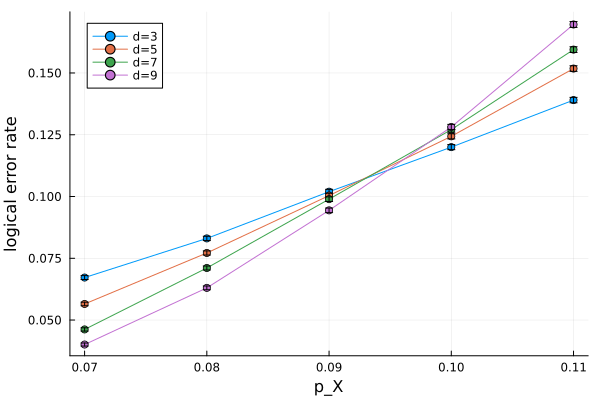

In [8]:
linecolors = get_color_palette(:auto, plot_color(:white))

g = plot()
for (ind_d, d) in enumerate(drange)
    p_success = [row[ind_d] for row in p_success_grid]
    p_fail = 1 .- p_success
    yerr = sqrt.(p_fail .* (1 .- p_fail) ./ num_total_samples)

    plot!(
        prange,
        p_fail;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
        yerr=yerr,
    )
end

plot!(
    xlabel="p_X",
    ylabel="logical error rate",
    # size=(900, 400),
)

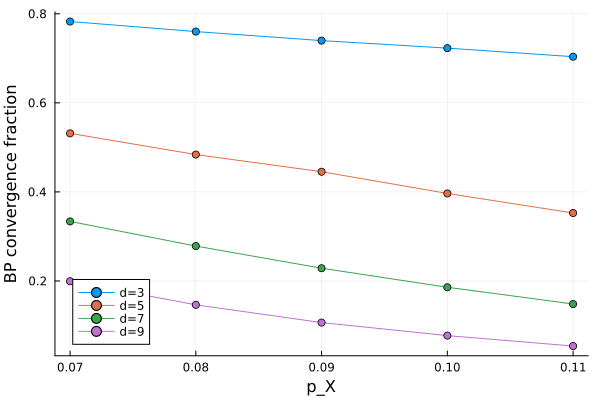

In [10]:
g2 = plot()
for (ind_d, d) in enumerate(drange)
    p_conv = [row[ind_d] for row in p_converged_grid]
    plot!(
        prange,
        p_conv;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
    )
end

plot!(
    xlabel="p_X",
    ylabel="BP convergence fraction",
    # size=(900, 400),
)

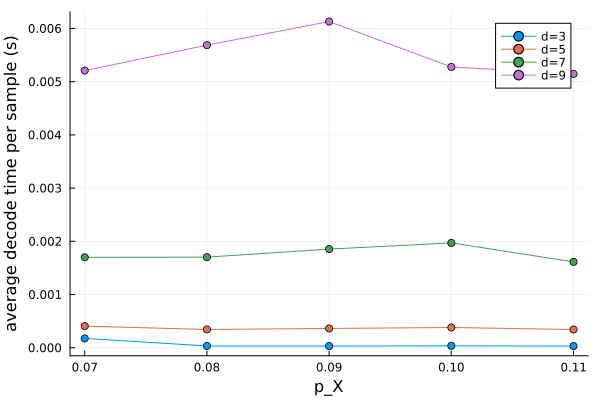

In [11]:
g3 = plot()
for (ind_d, d) in enumerate(drange)
    tavg = [row[ind_d] for row in t_grid]
    plot!(
        prange,
        tavg;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
    )
end

plot!(
    xlabel="p_X",
    ylabel="average decode time per sample (s)",
    # size=(900, 400),
)

## Notes

- This notebook decodes **X-only** noise, so it uses the **Z-check matrix** as the input parity-check matrix to `bp_osd_cs_decode`.
- Success is declared when the residual X error lies in the row space of the X stabilizers, i.e. when it is a stabilizer and not a logical X operator.
- The decoder is run with `osd_order = 0`, so this notebook measures **BP+OSD-0**, not higher-order combination sweep.


# Benchmark with bare BP

In [ ]:
@everywhere function run_surface_xnoise_batch_bare_bp(
    HX::AbstractMatrix{<:Integer},
    HZ::AbstractMatrix{<:Integer},
    p::Float64,
    num_samples::Int;
    max_iter::Int=size(HZ, 2),
)
    n = size(HZ, 2)

    num_success = 0
    num_converged = 0
    decode_time = 0.0

    for _ in 1:num_samples
        x_error = Int64.(rand(n) .< p)
        sx = mod.(HZ * x_error, 2)

        local result
        decode_time += @elapsed result = bp_decode(
            HZ, sx, p;
            max_iter=max_iter,
            check_to_bit_update_rule=:min_sum,
            bit_to_check_update_rule=:memoryless,
            min_sum_scaling=:roffe,
        )

        residual = mod.(x_error .+ result.error, 2)
        if is_in_rowspace_mod2(residual, HX)
            num_success += 1
        end

        if result.converged
            num_converged += 1
        end
    end

    return num_success, num_converged, decode_time
end

In [13]:
type_lattice = "surface_bp_xnoise"
logfile = "$(type_lattice)_$(dmin)_$(dmax)_$(prange[1])_$(prange[end])_$(num_total_samples)_log.txt"
open(logfile, "w") do file
end

@time results = pmap(1:num_cores) do _
    p_success_list = Dict(pd_range .=> 0.0)
    p_converged_list = Dict(pd_range .=> 0.0)
    t_list = Dict(pd_range .=> 0.0)

    HXs = Dict{Int, Matrix{Int64}}()
    HZs = Dict{Int, Matrix{Int64}}()

    for d in drange
        HXs[d] = stabilizer_dict_to_check_matrix(surface_code_X_stabilizers(d), d^2)
        HZs[d] = stabilizer_dict_to_check_matrix(surface_code_Z_stabilizers(d), d^2)
    end

    for (ind_pd, (p, d)) in enumerate(pd_range)
        HX = HXs[d]
        HZ = HZs[d]
        max_iter = max_iter_factor * size(HZ, 2)

        walltime = @elapsed begin
            num_success, num_converged, decode_time = run_surface_xnoise_batch_bare_bp(
                HX, HZ, p, num_samples_each_core;
                max_iter=max_iter,
            )

            p_success_list[(p, d)] += num_success
            p_converged_list[(p, d)] += num_converged
            t_list[(p, d)] += decode_time
        end

        if myid() == 2
            println("$(ind_pd)/$(length(pd_range)), d=$(d), p=$(p), walltime=$(walltime), $(string(now()))")
            open(logfile, "a") do file
                write(file, "$(ind_pd)/$(length(pd_range)), d=$(d), p=$(p), walltime=$(walltime), $(string(now()))\n")
            end
        end
    end

    return p_success_list, p_converged_list, t_list
end

p_success_list = merge(+, [res[1] for res in results]...)
p_converged_list = merge(+, [res[2] for res in results]...)
t_list = merge(+, [res[3] for res in results]...)

for key in keys(p_success_list)
    p_success_list[key] /= num_total_samples
    p_converged_list[key] /= num_total_samples
    t_list[key] /= num_total_samples
end

fn = "$(type_lattice)_$(dmin)_$(dmax)_$(prange[1])_$(prange[end])_$(num_total_samples).jld2"
jldsave(
    fn;
    prange=prange,
    drange=drange,
    num_samples=num_total_samples,
    p_success_list=p_success_list,
    p_converged_list=p_converged_list,
    t_list=t_list,
    max_iter_factor=max_iter_factor,
)

      From worker 2:	1/20, d=3, p=0.07, walltime=0.96172375, 2026-03-29T12:40:14.527
      From worker 2:	2/20, d=5, p=0.07, walltime=5.158106292, 2026-03-29T12:40:19.719
      From worker 2:	3/20, d=7, p=0.07, walltime=24.604812625, 2026-03-29T12:40:44.329
      From worker 2:	4/20, d=9, p=0.07, walltime=83.823285, 2026-03-29T12:42:08.150
      From worker 2:	5/20, d=3, p=0.08, walltime=0.719115042, 2026-03-29T12:42:08.875
      From worker 2:	6/20, d=5, p=0.08, walltime=5.879888417, 2026-03-29T12:42:14.756
      From worker 2:	7/20, d=7, p=0.08, walltime=25.952674458, 2026-03-29T12:42:40.721
      From worker 2:	8/20, d=9, p=0.08, walltime=80.742172292, 2026-03-29T12:44:01.460
      From worker 2:	9/20, d=3, p=0.09, walltime=0.54427275, 2026-03-29T12:44:02.010
      From worker 2:	10/20, d=5, p=0.09, walltime=6.431748625, 2026-03-29T12:44:08.443
      From worker 2:	11/20, d=7, p=0.09, walltime=25.89501875, 2026-03-29T12:44:34.338
      From worker 2:	12/20, d=9, p=0.09, walltime=87.

In [14]:
p_success_grid = get_grid_from_dict(p_success_list, drange, prange)
p_converged_grid = get_grid_from_dict(p_converged_list, drange, prange)
t_grid = get_grid_from_dict(t_list, drange, prange)

5-element Vector{Vector{Float64}}:
 [4.153381633000004e-5, 0.0002736108089000001, 0.0014030992923799999, 0.0047074985144900045]
 [3.311491975000005e-5, 0.00028964459059000055, 0.0013990449284299997, 0.0047207171264300055]
 [2.9076230070000033e-5, 0.00030330230798000004, 0.0014512457726099993, 0.004841005918689996]
 [3.317355222000002e-5, 0.00036149320179000013, 0.001613584295549999, 0.005098203975709994]
 [4.403011526000013e-5, 0.0003878615795499992, 0.0017045288835299997, 0.006727486298249996]

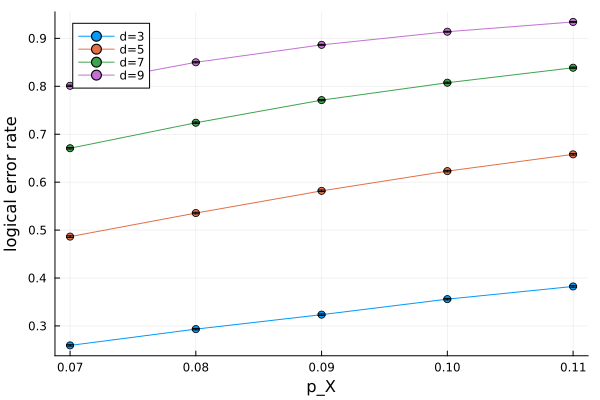

In [15]:
linecolors = get_color_palette(:auto, plot_color(:white))

g = plot()
for (ind_d, d) in enumerate(drange)
    p_success = [row[ind_d] for row in p_success_grid]
    p_fail = 1 .- p_success
    yerr = sqrt.(p_fail .* (1 .- p_fail) ./ num_total_samples)

    plot!(
        prange,
        p_fail;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
        yerr=yerr,
    )
end

plot!(
    xlabel="p_X",
    ylabel="logical error rate",
    # size=(900, 400),
)

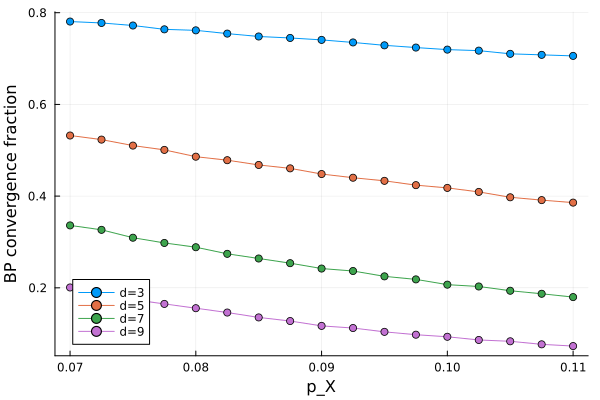

In [ ]:
g2 = plot()
for (ind_d, d) in enumerate(drange)
    p_conv = [row[ind_d] for row in p_converged_grid]
    plot!(
        prange,
        p_conv;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
    )
end

plot!(
    xlabel="p_X",
    ylabel="BP convergence fraction",
    # size=(900, 400),
)

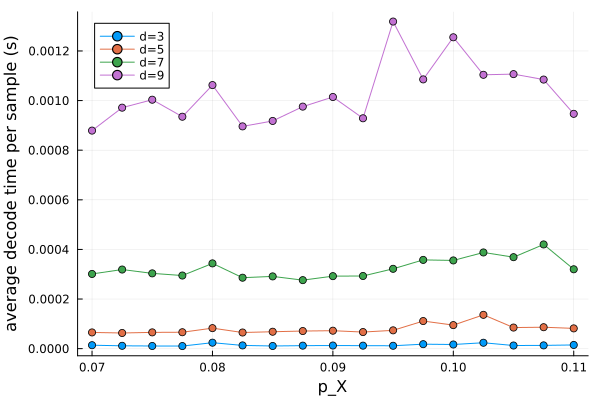

In [ ]:
g3 = plot()
for (ind_d, d) in enumerate(drange)
    tavg = [row[ind_d] for row in t_grid]
    plot!(
        prange,
        tavg;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
    )
end

plot!(
    xlabel="p_X",
    ylabel="average decode time per sample (s)",
    # size=(900, 400),
)

# Benchmark relay-bp

In [ ]:
@everywhere function run_surface_xnoise_batch_relay_bp(
    HX::AbstractMatrix{<:Integer},
    HZ::AbstractMatrix{<:Integer},
    p::Float64,
    num_samples::Int;
)
    n = size(HZ, 2)

    num_success = 0
    num_converged = 0
    decode_time = 0.0

    for _ in 1:num_samples
        x_error = Int64.(rand(n) .< p)
        sx = mod.(HZ * x_error, 2)

        local result
        decode_time += @elapsed result = relay_bp_decode(HZ, sx, p)

        residual = mod.(x_error .+ result.error, 2)
        if is_in_rowspace_mod2(residual, HX)
            num_success += 1
        end

        if result.converged
            num_converged += 1
        end
    end

    return num_success, num_converged, decode_time
end

In [ ]:
type_lattice = "surface_relay_bp_xnoise"
logfile = "$(type_lattice)_$(dmin)_$(dmax)_$(prange[1])_$(prange[end])_$(num_total_samples)_log.txt"
open(logfile, "w") do file
end

@time results = pmap(1:num_cores) do _
    p_success_list = Dict(pd_range .=> 0.0)
    p_converged_list = Dict(pd_range .=> 0.0)
    t_list = Dict(pd_range .=> 0.0)

    HXs = Dict{Int, Matrix{Int64}}()
    HZs = Dict{Int, Matrix{Int64}}()

    for d in drange
        HXs[d] = stabilizer_dict_to_check_matrix(surface_code_X_stabilizers(d), d^2)
        HZs[d] = stabilizer_dict_to_check_matrix(surface_code_Z_stabilizers(d), d^2)
    end

    for (ind_pd, (p, d)) in enumerate(pd_range)
        HX = HXs[d]
        HZ = HZs[d]

        walltime = @elapsed begin
            num_success, num_converged, decode_time = run_surface_xnoise_batch_relay_bp(
                HX, HZ, p, num_samples_each_core
            )

            p_success_list[(p, d)] += num_success
            p_converged_list[(p, d)] += num_converged
            t_list[(p, d)] += decode_time
        end

        if myid() == 2
            println("$(ind_pd)/$(length(pd_range)), d=$(d), p=$(p), walltime=$(walltime), $(string(now()))")
            open(logfile, "a") do file
                write(file, "$(ind_pd)/$(length(pd_range)), d=$(d), p=$(p), walltime=$(walltime), $(string(now()))\n")
            end
        end
    end

    return p_success_list, p_converged_list, t_list
end

p_success_list = merge(+, [res[1] for res in results]...)
p_converged_list = merge(+, [res[2] for res in results]...)
t_list = merge(+, [res[3] for res in results]...)

for key in keys(p_success_list)
    p_success_list[key] /= num_total_samples
    p_converged_list[key] /= num_total_samples
    t_list[key] /= num_total_samples
end

fn = "$(type_lattice)_$(dmin)_$(dmax)_$(prange[1])_$(prange[end])_$(num_total_samples).jld2"
jldsave(
    fn;
    prange=prange,
    drange=drange,
    num_samples=num_total_samples,
    p_success_list=p_success_list,
    p_converged_list=p_converged_list,
    t_list=t_list,
)

      From worker 2:	1/68, d=3, p=0.07, walltime=0.49226, 2026-03-24T15:44:38.028
      From worker 2:	2/68, d=5, p=0.07, walltime=2.6659735, 2026-03-24T15:44:40.742
      From worker 2:	3/68, d=7, p=0.07, walltime=10.267657667, 2026-03-24T15:44:51.011
      From worker 2:	4/68, d=9, p=0.07, walltime=22.2269725, 2026-03-24T15:45:13.239
      From worker 2:	5/68, d=3, p=0.0725, walltime=0.497701833, 2026-03-24T15:45:13.739
      From worker 2:	6/68, d=5, p=0.0725, walltime=2.929045833, 2026-03-24T15:45:16.672
      From worker 2:	7/68, d=7, p=0.0725, walltime=9.050793916, 2026-03-24T15:45:25.732
      From worker 2:	8/68, d=9, p=0.0725, walltime=23.699325625, 2026-03-24T15:45:49.434
      From worker 2:	9/68, d=3, p=0.075, walltime=0.63130075, 2026-03-24T15:45:50.069
      From worker 2:	10/68, d=5, p=0.075, walltime=2.806282583, 2026-03-24T15:45:52.878
      From worker 2:	11/68, d=7, p=0.075, walltime=8.991137958, 2026-03-24T15:46:01.869
      From worker 2:	12/68, d=9, p=0.075, wallt

In [ ]:
p_success_grid = get_grid_from_dict(p_success_list, drange, prange)
p_converged_grid = get_grid_from_dict(p_converged_list, drange, prange)
t_grid = get_grid_from_dict(t_list, drange, prange)

17-element Vector{Vector{Float64}}:
 [3.4128731250000015e-5, 0.00017346132437999988, 0.0006472407154100013, 0.0012856870009399996]
 [3.696228519000002e-5, 0.00020277331323999992, 0.0005836995286899989, 0.0013905675086300009]
 [3.552964688000007e-5, 0.00019856141987999998, 0.0005943038532800007, 0.0014021280850299996]
 [3.519884485000003e-5, 0.0001769703382799997, 0.0005317476371399999, 0.0012558105115699995]
 [3.3138138200000075e-5, 0.00018249758403000017, 0.0005376984814799994, 0.0012494786086999987]
 [3.726537919000004e-5, 0.00017927870569999985, 0.0005347351690999995, 0.0014532643788499973]
 [3.6019323260000096e-5, 0.00020908436465000036, 0.0006764929071200015, 0.0015597836221200023]
 [4.260905349000006e-5, 0.00021035654657999996, 0.0005583803795499999, 0.0013033691131700011]
 [3.622217631000009e-5, 0.00020429649821000003, 0.0006042276672999989, 0.0015429443663099974]
 [4.6240739830000015e-5, 0.0002589958015100001, 0.0006721325298299996, 0.0016273240950400048]
 [5.588278654999998e-5

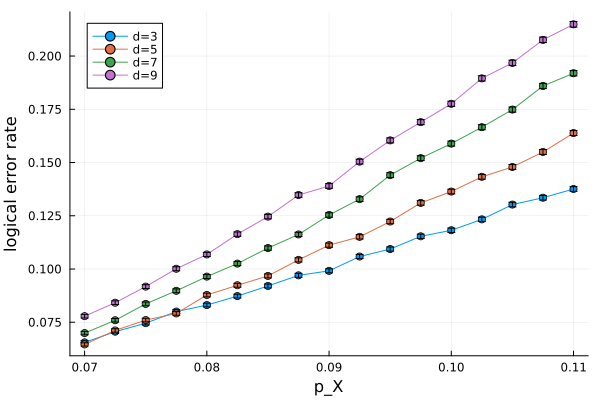

In [ ]:
linecolors = get_color_palette(:auto, plot_color(:white))

g = plot()
for (ind_d, d) in enumerate(drange)
    p_success = [row[ind_d] for row in p_success_grid]
    p_fail = 1 .- p_success
    yerr = sqrt.(p_fail .* (1 .- p_fail) ./ num_total_samples)

    plot!(
        prange,
        p_fail;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
        yerr=yerr,
    )
end

plot!(
    xlabel="p_X",
    ylabel="logical error rate",
    # size=(900, 400),
)

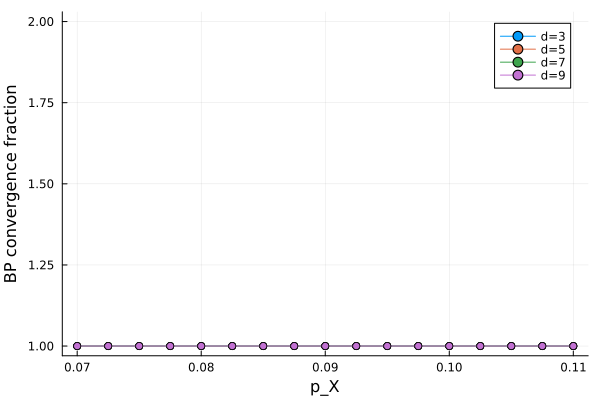

In [ ]:
g2 = plot()
for (ind_d, d) in enumerate(drange)
    p_conv = [row[ind_d] for row in p_converged_grid]
    plot!(
        prange,
        p_conv;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
    )
end

plot!(
    xlabel="p_X",
    ylabel="BP convergence fraction",
    # size=(900, 400),
)

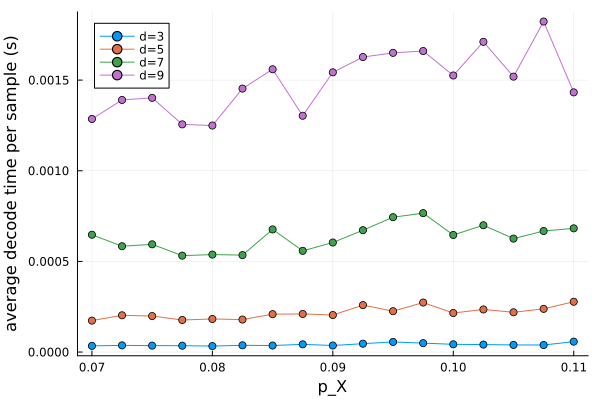

: 

In [ ]:
g3 = plot()
for (ind_d, d) in enumerate(drange)
    tavg = [row[ind_d] for row in t_grid]
    plot!(
        prange,
        tavg;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
    )
end

plot!(
    xlabel="p_X",
    ylabel="average decode time per sample (s)",
    # size=(900, 400),
)